In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import scipy.stats as stats

<h3>Preface</h3>
<p>Hi, it's Kat! The crab data has 3893 rows and 9 columns (aka features), each of which entail an individual crab. We're looking for K-means to predict some number of clusters marked 
by centroid points (maybe stars?) that will help us look at what makes each crab different or similar. Hopefully we can see what characteristics make up old, young,
or intermediate-aged crabs.</p>

As a guide, I'm using both resources from [Shivangi Singh](https://medium.com/swlh/k-means-clustering-on-high-dimensional-data-d2151e1a4240)'s Medium article/tutorial and [jakevdp](https://jakevdp.github.io/PythonDataScienceHandbook/05.11-k-means.html)'s associated page on Github.

<h3>Loading, Mapping, Scaling, and PCA Analysis</h3>

So, I don't really want to do 9 dimensions for the k-means for several reasons, including the fact there exists a "curse of dimensionality" that happens with the more dims you add. Given the trouble as well with handling multiple dimensions that extend beyond what the computer (and us, by proxy) can reasonably visualize, PCA or any dimensional reduction is necessary. Thus, I'm doing PCA analysis entailed [here from IBM](https://www.ibm.com/think/topics/principal-component-analysis) to bring the dims down to around N = 2 or 3.

Also see [this note about other dim reduction techs](https://www.analyticsvidhya.com/blog/2018/08/dimensionality-reduction-techniques-python/).

Along with this, you can see above in column 1 (index 0) that the Sex of the crabs is given as a qualitative value e.g., F, M, I. This isn't good for scaling, so I'm going to map the data into numerical values for easier use. Given now that everything is numerical, we can scale properly using StandardScaler(). The cells below are performing loading and mapping, scaling, and PCA analysis respectively. 

In [43]:
rawCrab = pd.read_csv('resources/crabagedataset.csv')

rawCrab["Sex"] = rawCrab["Sex"].map({"M": 1, "F": 2, "I": 3})

rawCrab.shape # checking the shape
print(f'{rawCrab.shape} for (row, col).')

rawCrab.head()

(3893, 9) for (row, col).


,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
0,2,1.4375,1.1750,0.4125,24.635715,12.332033,5.584852,6.747181,9
1,1,0.8875,0.6500,0.2125,5.400580,2.296310,1.374951,1.559222,6
2,3,1.0375,0.7750,0.2500,7.952035,3.231843,1.601747,2.764076,6
3,2,1.1750,0.8875,0.2500,13.480187,4.748541,2.282135,5.244657,10
4,3,0.8875,0.6625,0.2125,6.903103,3.458639,1.488349,1.700970,6


In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaleData = StandardScaler().fit_transform(rawCrab) # this scales everything now that the Sex column is full of numerical values, each for F/M/I
scaledCrab = pd.DataFrame(scaleData, columns = rawCrab.columns) # see below, a fully quantitative dataset with extra cols for all 3 sexes

scaledCrab

,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
0,0.062802,0.420099,0.620895,0.601415,0.076925,0.338625,0.144441,-0.012342,-0.296468
1,-1.147529,-1.410841,-1.494328,-1.304023,-1.307952,-1.260829,-1.211958,-1.328119,-1.227985
2,1.273132,-0.911494,-0.990703,-0.946754,-1.124255,-1.111727,-1.138886,-1.022543,-1.227985
3,0.062802,-0.453759,-0.537441,-0.946754,-0.726243,-0.870002,-0.919670,-0.393414,0.014038
4,1.273132,-1.410841,-1.443965,-1.304023,-1.199775,-1.075582,-1.175422,-1.292169,-1.227985
...,...,...,...,...,...,...,...,...,...
3888,0.062802,0.503324,0.469808,-0.232215,0.090192,0.230187,0.231214,-0.105813,-0.606974
3889,0.062802,0.794610,0.771983,0.839594,0.784161,0.835630,0.655944,0.756992,0.014038
3890,1.273132,-2.284700,-2.249764,-1.780383,-1.551862,-1.504814,-1.485978,-1.561796,-1.538491
3891,1.273132,-0.828269,-0.990703,-0.827664,-0.951783,-0.908407,-0.901402,-0.968617,-1.227985


In [45]:
# PCA analysis
pca3NSet = PCA(n_components = 3)
pca3NDF = pca3NSet.fit_transform(scaledCrab)
pca3DimCrab = pd.DataFrame(pca3NDF)
pca3DimCrab # isn't that satisfying? we've now crunched effectively 9 columns down into 3

,0,1,2
0,0.692695,0.404707,-0.242616
1,-3.407608,-1.389264,-1.305400
2,-3.152571,0.801037,-0.030607
3,-1.738276,-0.512231,0.269831
4,-3.745152,0.676536,-0.085591
...,...,...,...
3888,0.280818,0.504542,-0.573531
3889,1.940163,0.638527,-0.129124
3890,-5.083571,0.446970,-0.241766
3891,-2.841305,0.916858,-0.100558


<h3>Initial Cluster Visualization</h3>
Now that I've crunched these components into 3 dims of essentially what "matters" when we find crab age, it's time to find any initial patterns in the data. For this part of the clustering, I'll use the methods taught in Lab 3. For reference, I'll also PCA crunch the dataset into 2 dims for easier visualization. You can also move these around because I used ipympl!

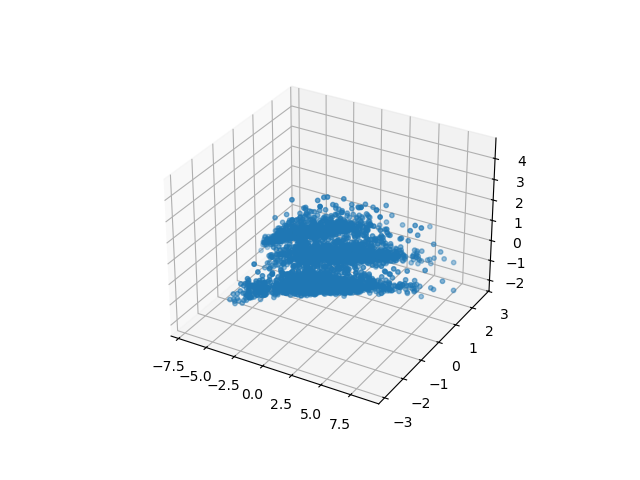

In [46]:
import ipympl

fig = plt.figure()
ax = plt.axes(projection = '3d')
plt.axis('equal')

ax.scatter(pca3DimCrab.iloc[:, 0], pca3DimCrab.iloc[:, 1], pca3DimCrab.iloc[:, 2], s = 10)

plt.show()

In [47]:
pca2NSet = PCA(n_components = 2)
pca2NDF = pca2NSet.fit_transform(scaledCrab)
pca2DimCrab = pd.DataFrame(pca2NDF)
pca2DimCrab # and for curiosity, I also did it in 2 dims just so you can see how this works. 

,0,1
0,0.692695,0.404707
1,-3.407608,-1.389264
2,-3.152571,0.801037
3,-1.738276,-0.512231
4,-3.745152,0.676536
...,...,...
3888,0.280818,0.504542
3889,1.940163,0.638527
3890,-5.083571,0.446970
3891,-2.841305,0.916858


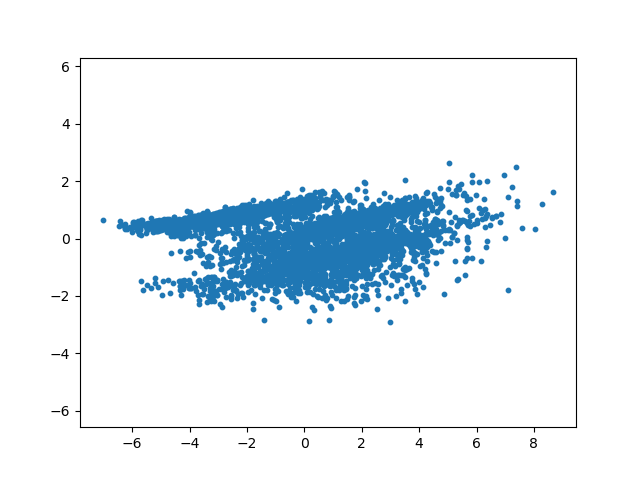

In [48]:
fig = plt.figure()
ax = plt.axes()
plt.axis('equal')

ax.scatter(pca2DimCrab.iloc[:, 0], pca2DimCrab.iloc[:, 1], s = 10)

plt.show()

<h3>Finding k with the Elbow Method</h3>

So, we see how the newly-crunched components are visualized and how muc data PCA has essentially "taken away" in order to condense the information. The cumulative variance, in this situation, is a measure of how much data is retained after PCA. Even though we can see above that there are 3 apparent clusters, I would still like to try the elbow method to establish k for the KMeans operation. For this step, I'm referencing [an article](https://medium.com/analytics-vidhya/how-to-determine-the-optimal-k-for-k-means) on the elbow method to get the general intuition going. We essentially need to find the Within-Cluster Sum of Squares (WSS) and find where it decreases dramatically. WSS is modeled in the scikit KMeans package as the inertia_ command, which simplifies things a lot.

Documentation for KMeans [here](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).

In [59]:
from sklearn.cluster import KMeans
# from scipy.spatial.distance import cdist

def findWss(set, kmax):
    squareErr = []
    for k in range(1, kmax + 1):
        kmeans = KMeans(n_clusters = k)
        kmeans.fit(set)
        squareErr.append(kmeans.inertia_)
    return squareErr

kMax = 10 # yes i know i'm like so good at names
wssValues = findWss(pca3NDF, kMax) 

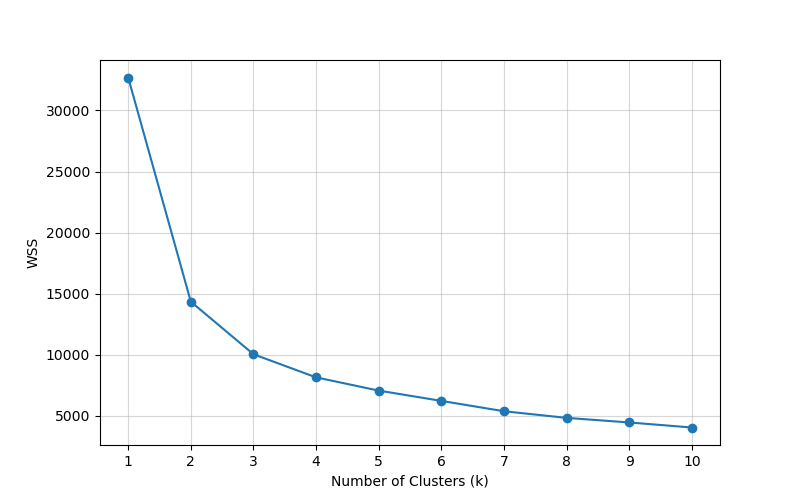

In [63]:
plt.figure(figsize = (8, 5))
plt.plot(range(1, kMax + 1), wssValues, marker = 'o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WSS')
plt.xticks(range(1, kMax + 1))
plt.grid(alpha = 0.5)
plt.show()

Now we can confirm that three clusters (k = 3) is the optimal value for k for the actual Kmeans! The elbow is where the rate of change vastly decreases for WSS, as seen above in how the slope after k = 3 sort of flattens out. 

<h3>Actually Clustering This Time</h3>
Now that we've found the optimal value for k, we can fit the kmeans clustering and establish centroids marking different groups in the crab dataset. I'll do this for both 2D and 3D.

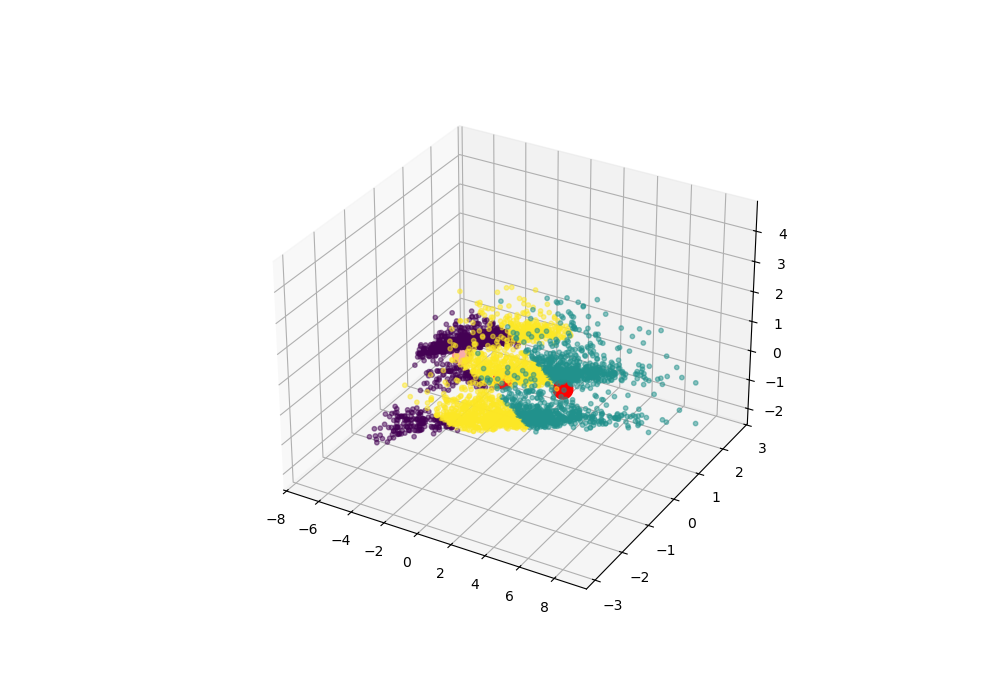

In [64]:
optimalK = 3 # due to visible elbow and change in rate
KMeansReal = KMeans(n_clusters = optimalK)
KMeansReal.fit(pca3DimCrab)

labels = KMeansReal.labels_
centroids = KMeansReal.cluster_centers_

plt.figure(figsize = (10, 7))
ax = plt.axes(projection = '3d')
plt.axis('equal')
ax.scatter(pca3DimCrab.iloc[:, 0], pca3DimCrab.iloc[:, 1], pca3DimCrab.iloc[:, 2], s = 10, c = labels, alpha = 0.5)
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], s = 200, label = 'Centroids', c = 'red')
plt.show()

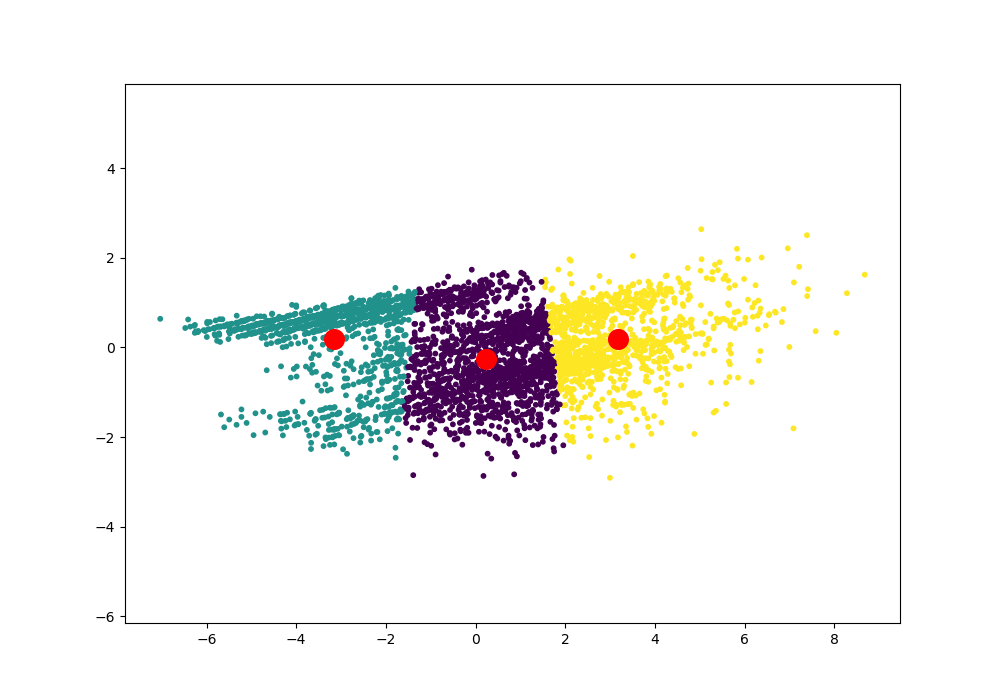

In [65]:
optimalK = 3 # due to visible elbow and change in rate
KMeansReal = KMeans(n_clusters = optimalK)
KMeansReal.fit(pca2DimCrab)

labels = KMeansReal.labels_
centroids = KMeansReal.cluster_centers_

plt.figure(figsize = (10, 7))
ax = plt.axes()
plt.axis('equal')
ax.scatter(pca2DimCrab.iloc[:, 0], pca2DimCrab.iloc[:, 1], s = 10, c = labels)
ax.scatter(centroids[:, 0], centroids[:, 1], s = 200, label = 'Centroids', c = 'red')
plt.show()

This concludes the KMeans Clustering portion.